   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None
       PassengerId    Survived
count   418.000000  418.000000
mean   1100.500000    0.363636
std     120.810458    0.481622
min     892.000000    0.000000
25%     996.250000    0.000000
50%    1100.500000    0.000000
75%    1204.750000    1.000000
max    1309.000000    1.000000
PassengerId    0
Survived       0
dtype: int64
PassengerId    int64
Survived       int64
dtype: object
Dropped Columns:
Index([], dtype='object')
PassengerId    0
Survived       0
dtype: int64


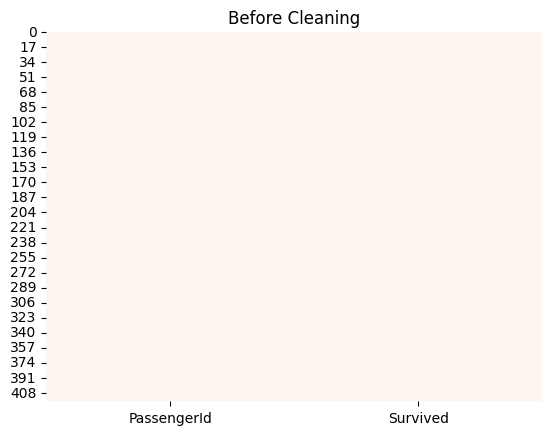

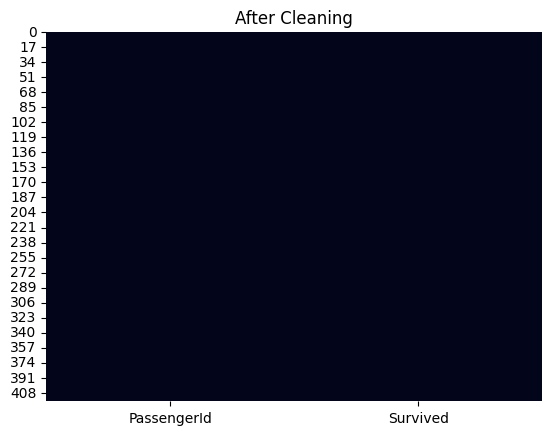

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [15]:
!pip install pandera
import pandas as pd

# Load dataset
df = pd.read_csv("/content/gender_submission (2).csv")

# Create a copy for 'Before Cleaning' visualization
df_original = df.copy()

# First 5 rows
print(df.head())

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Missing values
print(df.isnull().sum())

# Data types
print(df.dtypes)

# Categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Unique values
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())

# Define threshold outside the loop
threshold = 40

missing_percent = (df.isnull().sum() / len(df)) * 100

cols_to_drop = missing_percent[missing_percent > threshold].index

df = df.drop(columns=cols_to_drop)

print("Dropped Columns:")
print(cols_to_drop)
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Median imputation for numerical data
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Mode imputation for categorical data
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())
import seaborn as sns
import matplotlib.pyplot as plt

# Plot Before Cleaning
plt.figure() # Create a new figure for this plot
sns.heatmap(df_original.isnull(), cbar=False, cmap='Reds')
plt.title("Before Cleaning")
plt.show()

# Plot After Cleaning
plt.figure() # Create a new figure for this plot
sns.heatmap(df.isnull(), cbar=False)
plt.title("After Cleaning")
plt.show()
import pandera as pa

schema = pa.DataFrameSchema({
    "PassengerId": pa.Column(
        int,
        checks=pa.Check.greater_than(0)
    ),

    "Survived": pa.Column(
        int,
        checks=pa.Check.isin([0, 1])
    )
})

schema.validate(df)